# Lab 16: Data Visualization using SQL and SQLite
## IBM Data Analytics Capstone Project 
### Objective: Extract data using SQL queries and create visualizations including histograms, box plots, scatter plots, bubble plots, pie charts, stacked charts, line charts and bar charts

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import numpy as np

# Load the dataset
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [2]:
# Create SQLite database
conn = sqlite3.connect('survey-data.sqlite')
df.to_sql('main', conn, if_exists='replace', index=False)
conn.close()
print("SQLite database created successfully!")

# Verify data
conn = sqlite3.connect('survey-data.sqlite')
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)
print("\nFirst 5 rows from SQLite:")
print(df_check[['ResponseId', 'Age', 'Employment', 'RemoteWork']].head())

SQLite database created successfully!

First 5 rows from SQLite:
   ResponseId                 Age           Employment RemoteWork
0           1  Under 18 years old  Employed, full-time     Remote
1           2     35-44 years old  Employed, full-time     Remote
2           3     45-54 years old  Employed, full-time     Remote
3           4     18-24 years old   Student, full-time       None
4           5     18-24 years old   Student, full-time       None


In [3]:
# Count rows
QUERY = "SELECT COUNT(*) as Total_Rows FROM main"
print("Total rows:")
print(pd.read_sql_query(QUERY, conn))

# List all tables
QUERY = "SELECT name as Table_Name FROM sqlite_master WHERE type='table'"
print("\nTables in database:")
print(pd.read_sql_query(QUERY, conn))

# Group by Age
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
print("\nRespondents by Age Group:")
print(pd.read_sql_query(QUERY, conn))

Total rows:
   Total_Rows
0       65437

Tables in database:
  Table_Name
0       main

Respondents by Age Group:
                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


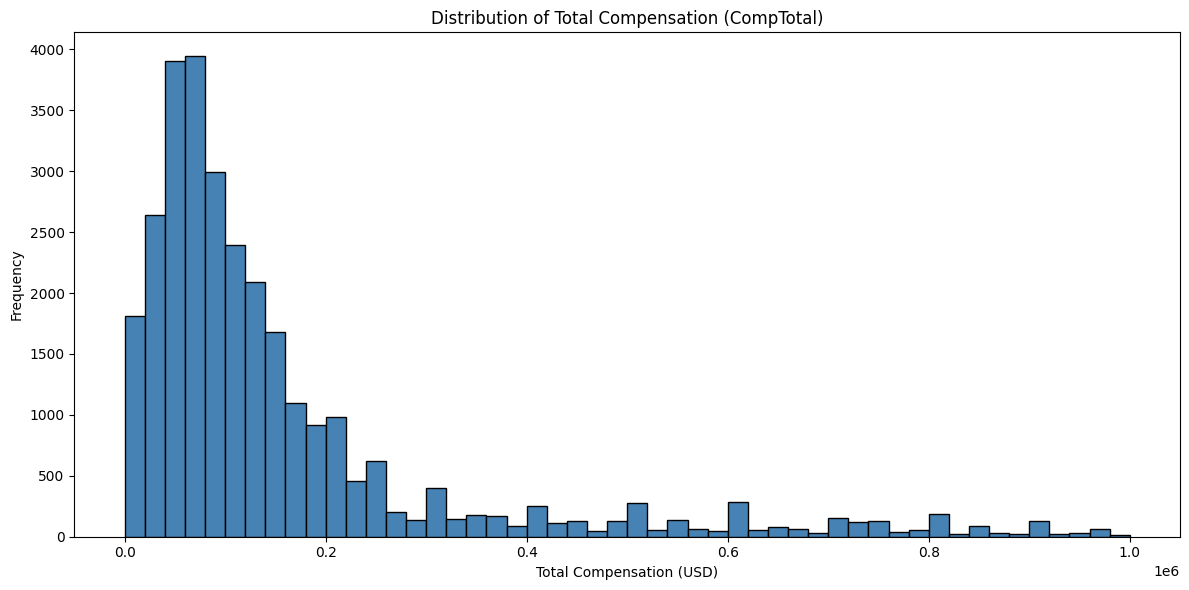

Histogram saved!


In [4]:
# Query CompTotal from SQLite
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND CompTotal < 1000000"
df_comp = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(12, 6))
plt.hist(df_comp['CompTotal'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('Total Compensation (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('histogram_comptotal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Histogram saved!")

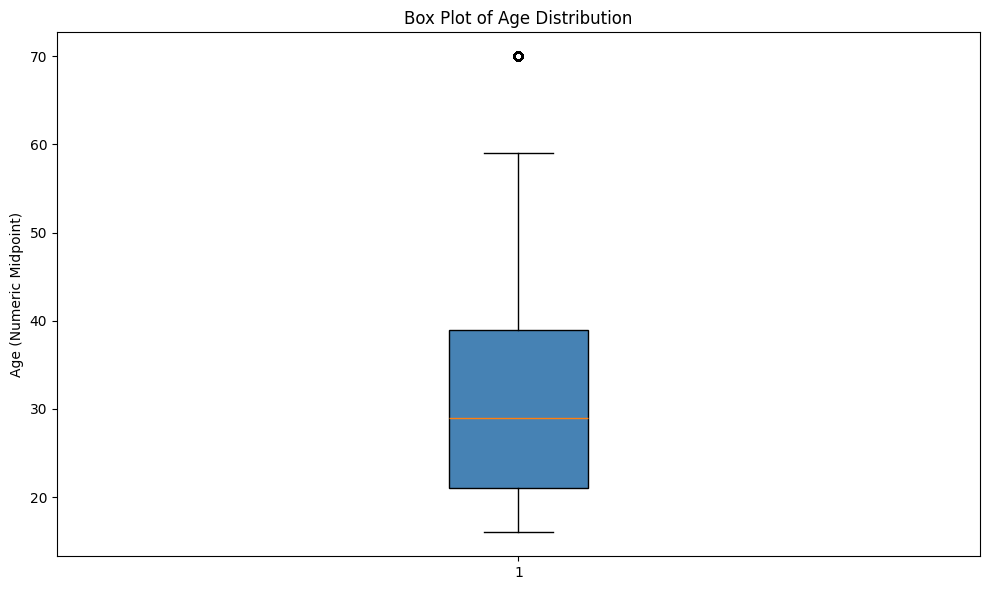

Box plot saved!


In [5]:
# Query Age counts from SQLite
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
WHERE Age IS NOT NULL 
GROUP BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)

# Map age to numeric for box plot
age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70
}
QUERY = "SELECT Age FROM main WHERE Age IS NOT NULL AND Age != 'Prefer not to say'"
df_age_raw = pd.read_sql_query(QUERY, conn)
df_age_raw['Age_Numeric'] = df_age_raw['Age'].map(age_mapping)

plt.figure(figsize=(10, 6))
plt.boxplot(df_age_raw['Age_Numeric'].dropna(), patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Box Plot of Age Distribution')
plt.ylabel('Age (Numeric Midpoint)')
plt.tight_layout()
plt.savefig('boxplot_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved!")

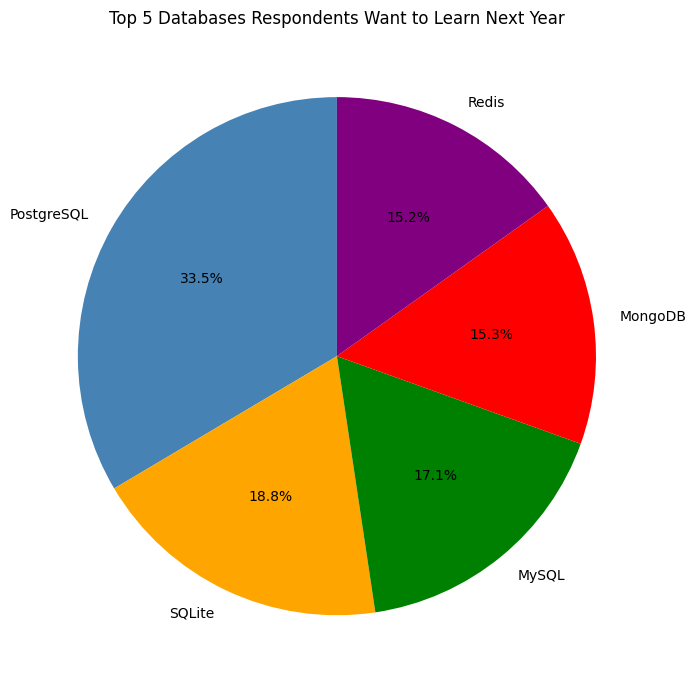

Pie chart saved!

Top 5 Databases:
DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


In [6]:
# Query top 5 databases respondents want to learn
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

# Split and count
db_series = df_db['DatabaseWantToWorkWith'].str.split(';').explode()
top5_db = db_series.value_counts().head(5)

plt.figure(figsize=(10, 7))
plt.pie(top5_db.values, labels=top5_db.index, 
        autopct='%1.1f%%', startangle=90,
        colors=['steelblue','orange','green','red','purple'])
plt.title('Top 5 Databases Respondents Want to Learn Next Year')
plt.tight_layout()
plt.savefig('pie_databases.png', dpi=150, bbox_inches='tight')
plt.show()
print("Pie chart saved!")
print("\nTop 5 Databases:")
print(top5_db)

               Age  avg_searching  avg_answering
0  25-34 years old      26.788881      21.544452
1  35-44 years old      25.209384      23.262487


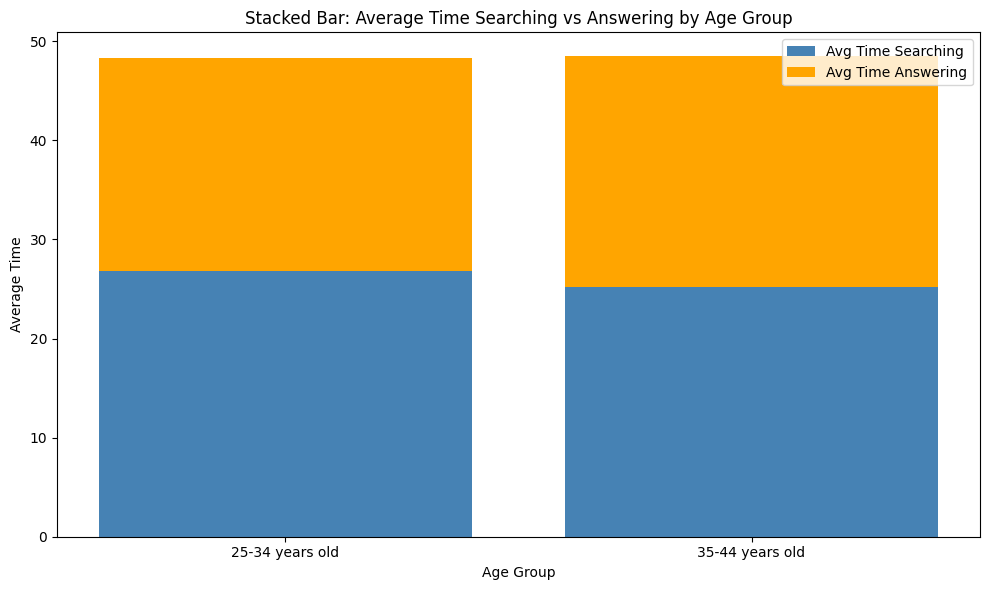

Stacked bar chart saved!


In [7]:
# Query TimeSearching and TimeAnswering for age group 25-34
QUERY = """
SELECT Age, 
       AVG(CAST(TimeSearching AS FLOAT)) as avg_searching,
       AVG(CAST(TimeAnswering AS FLOAT)) as avg_answering
FROM main
WHERE Age IN ('25-34 years old', '35-44 years old')
AND TimeSearching IS NOT NULL
AND TimeAnswering IS NOT NULL
GROUP BY Age
"""
df_stacked = pd.read_sql_query(QUERY, conn)
print(df_stacked)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = df_stacked['Age']
ax.bar(x, df_stacked['avg_searching'], label='Avg Time Searching', color='steelblue')
ax.bar(x, df_stacked['avg_answering'], bottom=df_stacked['avg_searching'], 
       label='Avg Time Answering', color='orange')
ax.set_title('Stacked Bar: Average Time Searching vs Answering by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Time')
ax.legend()
plt.tight_layout()
plt.savefig('stacked_bar_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("Stacked bar chart saved!")

               Age    median_comp
0  45-54 years old  169731.593458
1  55-64 years old  168968.249178


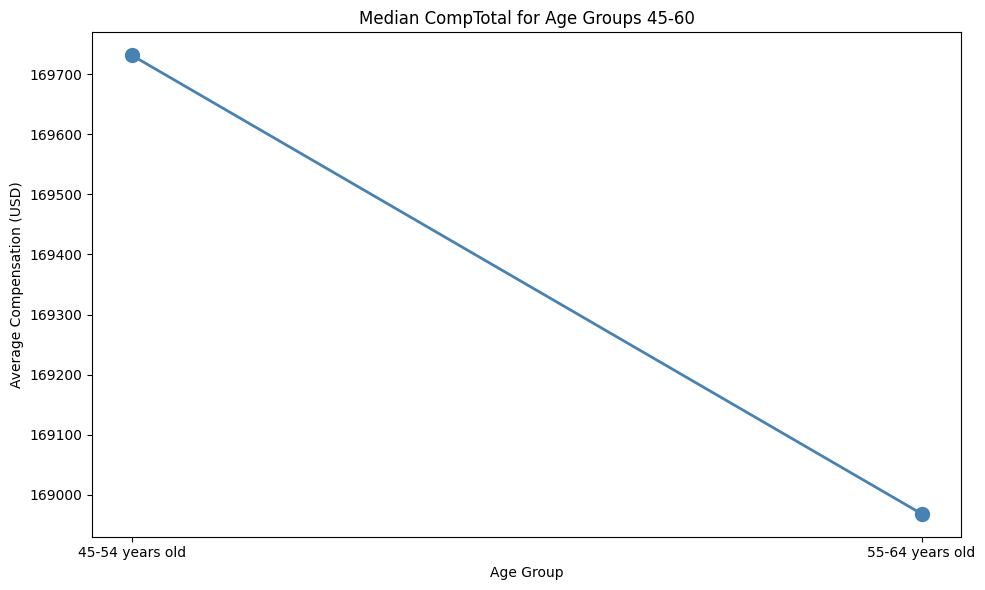

Line chart saved!


In [8]:
# Query median CompTotal for ages 45-60
QUERY = """
SELECT Age, AVG(CompTotal) as median_comp
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
AND CompTotal IS NOT NULL
AND CompTotal < 1000000
GROUP BY Age
ORDER BY Age
"""
df_line = pd.read_sql_query(QUERY, conn)
print(df_line)

plt.figure(figsize=(10, 6))
plt.plot(df_line['Age'], df_line['median_comp'], 
         marker='o', color='steelblue', linewidth=2, markersize=10)
plt.title('Median CompTotal for Age Groups 45-60')
plt.xlabel('Age Group')
plt.ylabel('Average Compensation (USD)')
plt.tight_layout()
plt.savefig('line_comp_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print("Line chart saved!")

                                          MainBranch  count
0                     I am a developer by profession  50207
1  I am not primarily a developer, but I write co...   6511
2                              I am learning to code   3875
3                        I code primarily as a hobby   3334
4  I used to be a developer by profession, but no...   1510


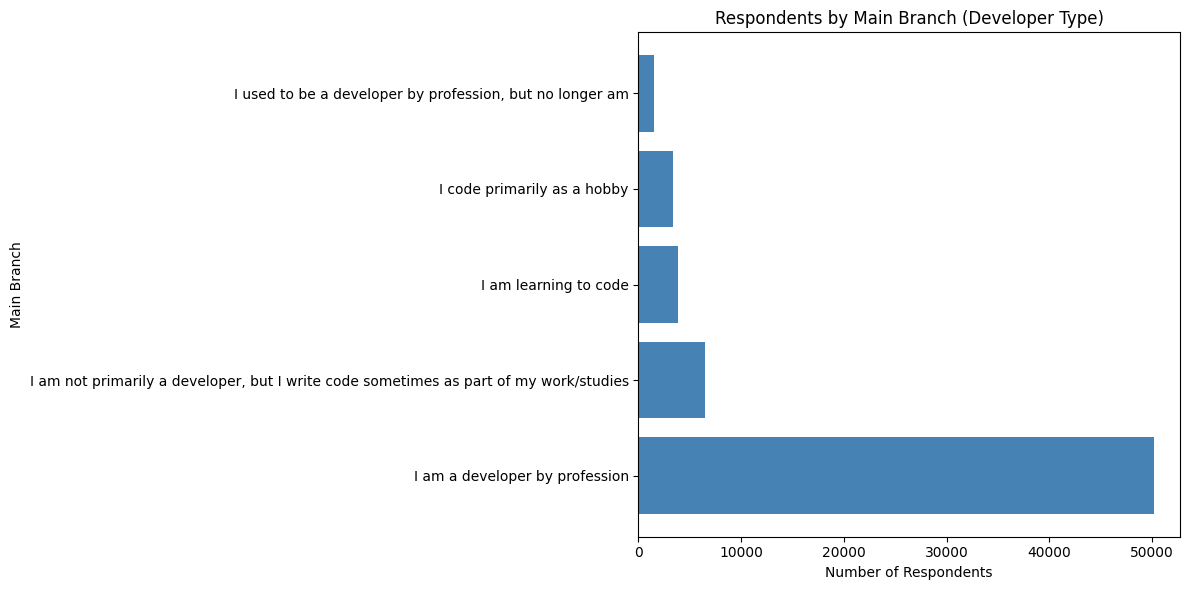

✅ Bar chart saved!
Database connection closed!


In [9]:
# Query MainBranch distribution
QUERY = """
SELECT MainBranch, COUNT(*) as count
FROM main
WHERE MainBranch IS NOT NULL
GROUP BY MainBranch
ORDER BY count DESC
"""
df_branch = pd.read_sql_query(QUERY, conn)
print(df_branch)

plt.figure(figsize=(12, 6))
plt.barh(df_branch['MainBranch'], df_branch['count'], color='steelblue')
plt.title('Respondents by Main Branch (Developer Type)')
plt.xlabel('Number of Respondents')
plt.ylabel('Main Branch')
plt.tight_layout()
plt.savefig('bar_mainbranch.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Bar chart saved!")

# Close connection
conn.close()
print("Database connection closed!")